In [2]:
import pandas as pd

In [3]:
data = pd.read_csv("../../../data/raw/kathmandu_full_raw_2023_2024.csv")

In [4]:
data['time'] = pd.to_datetime(data['time'])

### 13. Analyze monthly and seasonal variations

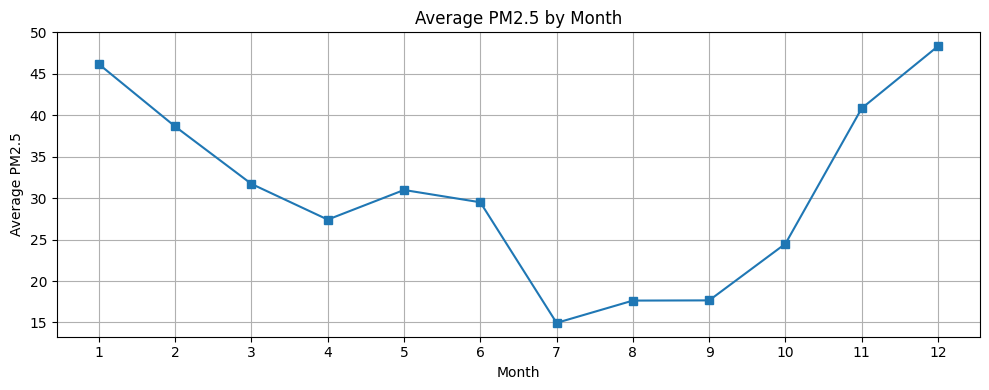

In [5]:
import matplotlib.pyplot as plt

data['month'] = data['time'].dt.month
monthly_avg = data.groupby('month')['pm2_5'].mean()

plt.figure(figsize=(10, 4))
plt.plot(monthly_avg.index, monthly_avg.values, marker='s')
plt.title('Average PM2.5 by Month')
plt.xlabel('Month')
plt.ylabel('Average PM2.5')
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()

#### 13.1 Sample months hourly analysis

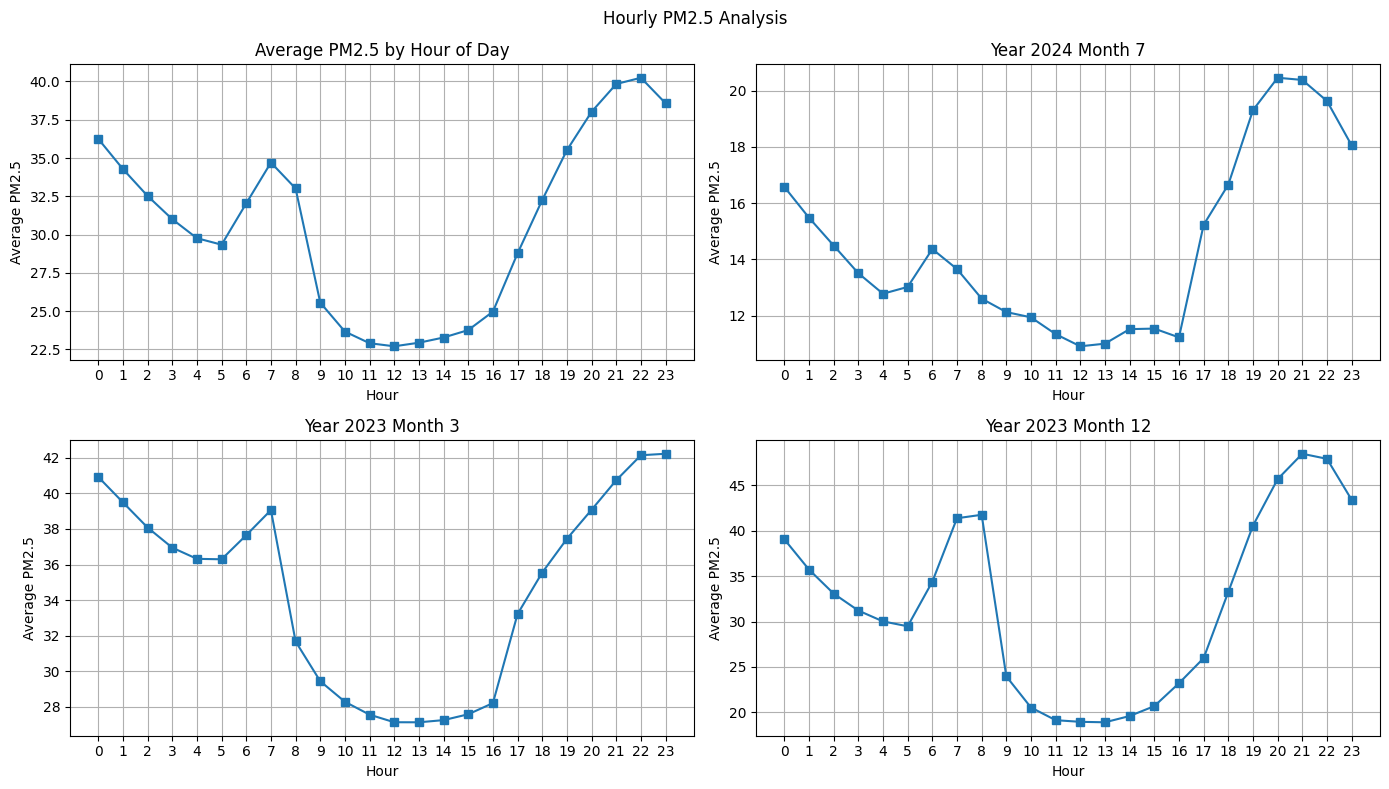

In [6]:
data['hour'] = data['time'].dt.hour
data['month'] = data['time'].dt.month
data['year'] = data['time'].dt.year

hourly_avg = data.groupby('hour')['pm2_5'].mean()
months = data[['year', 'month']].drop_duplicates().sample(3, random_state=44).values

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

axes[0].plot(hourly_avg.index, hourly_avg.values, marker='s')
axes[0].set_title('Average PM2.5 by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Average PM2.5')
axes[0].set_xticks(range(0, 24))
axes[0].grid(True)

for i, (year, month) in enumerate(months):
    mask = (data['year'] == year) & (data['month'] == month)
    month_data = data[mask].groupby('hour')['pm2_5'].mean()
    axes[i + 1].plot(month_data.index, month_data.values, marker='s')
    axes[i + 1].set_title(f'Year {year} Month {month}')
    axes[i + 1].set_xlabel('Hour')
    axes[i + 1].set_ylabel('Average PM2.5')
    axes[i + 1].set_xticks(range(0, 24))
    axes[i + 1].grid(True)

plt.suptitle('Hourly PM2.5 Analysis')
plt.tight_layout()
plt.show()

### 14. Compute moving averages and moving volatility

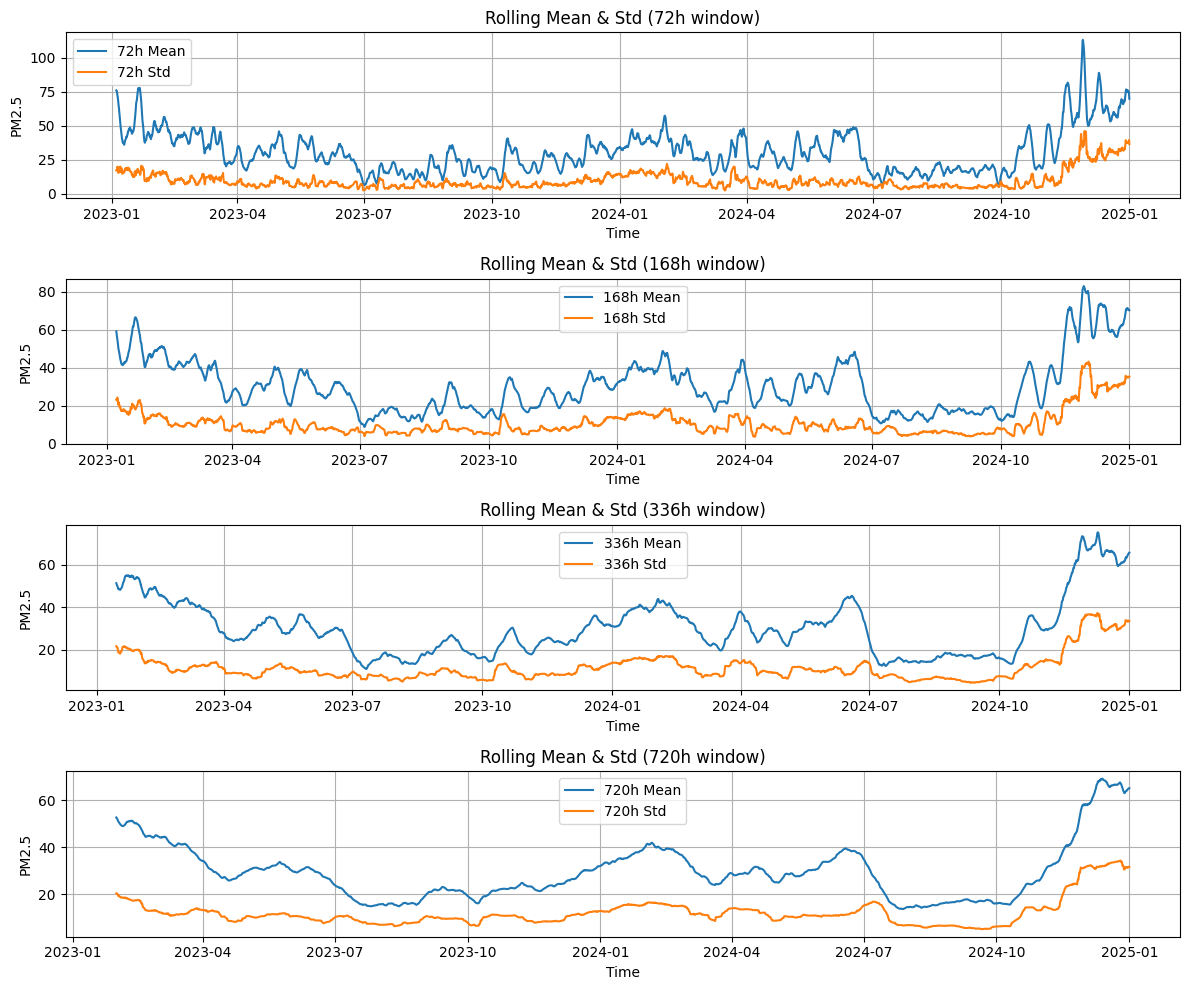

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10))
axes = axes.flatten()

windows = [72, 168, 336, 720]

for i, w in enumerate(windows):
    axes[i].plot(data['time'], data['pm2_5'].rolling(window=w).mean(), label=f'{w}h Mean')
    axes[i].plot(data['time'], data['pm2_5'].rolling(window=w).std(), label=f'{w}h Std')
    axes[i].set_title(f'Rolling Mean & Std ({w}h window)')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('PM2.5')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()